In [ ]:
# ============================================================
# SWYNEX TECHNOLOGIES - TASK 1
# NETFLIX DATA CLEANING & PREPARATION
# ============================================================

# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

print("=" * 60)
print("SWYNEX TECHNOLOGIES")
print("NETFLIX DATA CLEANING & PREPARATION")
print("=" * 60)



SWYNEX TECHNOLOGIES
NETFLIX DATA CLEANING & PREPARATION


In [ ]:

# ============================================================
# 2. UPLOAD DATASET
# ============================================================

print("\nUpload netflix_titles.csv")

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

print("\nDataset loaded successfully!")



Upload netflix_titles.csv


Saving netflix_titles.csv to netflix_titles (1).csv

Dataset loaded successfully!


In [ ]:
# ============================================================
# 3. INITIAL DATASET INSPECTION
# ============================================================

print("\n" + "=" * 60)
print("1. DATASET OVERVIEW")
print("=" * 60)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nFirst 5 records:")
display(df.head())

print("\nColumn names:")
print(df.columns.tolist())



1. DATASET OVERVIEW
Rows: 8807
Columns: 12

First 5 records:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...



Column names:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']


In [ ]:
# ============================================================
# 4. DATA TYPES
# ============================================================

print("\n" + "=" * 60)
print("2. DATA TYPES")
print("=" * 60)

print(df.dtypes)



2. DATA TYPES
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object


In [ ]:
# ============================================================
# 5. MISSING VALUE ANALYSIS
# ============================================================

print("\n" + "=" * 60)
print("3. MISSING VALUE ANALYSIS")
print("=" * 60)

missing = df.isnull().sum()

missing_percent = (
    df.isnull().sum() / len(df) * 100
).round(2)

missing_report = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": missing_percent
})

missing_report = missing_report[
    missing_report["Missing Values"] > 0
].sort_values(
    "Missing Values",
    ascending=False
)

display(missing_report)



3. MISSING VALUE ANALYSIS


,Missing Values,Percentage
director,2634,29.91
country,831,9.44
cast,825,9.37
date_added,10,0.11
rating,4,0.05
duration,3,0.03


In [ ]:
# ============================================================
# 6. DUPLICATE ANALYSIS
# ============================================================

print("\n" + "=" * 60)
print("4. DUPLICATE ANALYSIS")
print("=" * 60)

duplicates = df.duplicated().sum()

print("Duplicate records found:", duplicates)



4. DUPLICATE ANALYSIS
Duplicate records found: 0


In [ ]:
# ============================================================
# 7. CREATE CLEANING COPY
# ============================================================

clean_df = df.copy()

In [ ]:
# ============================================================
# 8. REMOVE DUPLICATES
# ============================================================

clean_df = clean_df.drop_duplicates()

print("\nDuplicates removed.")
print("Rows after duplicate removal:", len(clean_df))


Duplicates removed.
Rows after duplicate removal: 8807


In [ ]:
# ============================================================
# 9. STANDARDIZE TEXT COLUMNS
# ============================================================

print("\n" + "=" * 60)
print("5. TEXT STANDARDIZATION")
print("=" * 60)

text_columns = clean_df.select_dtypes(
    include="object"
).columns

for column in text_columns:

    clean_df[column] = (
        clean_df[column]
        .astype("string")
        .str.strip()
    )

print("Leading and trailing spaces standardized.")




5. TEXT STANDARDIZATION
Leading and trailing spaces standardized.


In [ ]:
# ============================================================
# 10. HANDLE MISSING VALUES
# ============================================================

print("\n" + "=" * 60)
print("6. MISSING VALUE TREATMENT")
print("=" * 60)

# Columns where missing information can be represented
# with a meaningful category
category_columns = [
    "director",
    "cast",
    "country",
    "rating",
    "duration"
]

for column in category_columns:

    if column in clean_df.columns:

        clean_df[column] = (
            clean_df[column]
            .fillna("Unknown")
        )

        print(
            column,
            "-> missing values replaced with 'Unknown'"
        )


6. MISSING VALUE TREATMENT
director -> missing values replaced with 'Unknown'
cast -> missing values replaced with 'Unknown'
country -> missing values replaced with 'Unknown'
rating -> missing values replaced with 'Unknown'
duration -> missing values replaced with 'Unknown'


In [ ]:
# ============================================================
# 11. CONVERT DATE COLUMN
# ============================================================

print("\n" + "=" * 60)
print("7. DATE TYPE CORRECTION")
print("=" * 60)

clean_df["date_added"] = pd.to_datetime(
    clean_df["date_added"],
    errors="coerce"
)

print(
    "date_added data type:",
    clean_df["date_added"].dtype
)




7. DATE TYPE CORRECTION
date_added data type: datetime64[ns]


In [ ]:
# ============================================================
# 12. STANDARDIZE CATEGORIES
# ============================================================

print("\n" + "=" * 60)
print("8. CATEGORY STANDARDIZATION")
print("=" * 60)

clean_df["type"] = (
    clean_df["type"]
    .str.strip()
    .str.title()
)

clean_df["rating"] = (
    clean_df["rating"]
    .str.strip()
    .str.upper()
)

print("Type and rating categories standardized.")




8. CATEGORY STANDARDIZATION
Type and rating categories standardized.


In [ ]:
# ============================================================
# 13. VALIDATE NUMERICAL / CATEGORICAL VALUES
# ============================================================

print("\n" + "=" * 60)
print("9. DATA VALIDATION")
print("=" * 60)

print("\nContent types:")
print(
    clean_df["type"].value_counts()
)

print("\nInvalid content types:")

valid_types = [
    "Movie",
    "Tv Show"
]

invalid_types = clean_df[
    ~clean_df["type"].isin(valid_types)
]

print(
    len(invalid_types)
)



9. DATA VALIDATION

Content types:
type
Movie      6131
Tv Show    2676
Name: count, dtype: Int64

Invalid content types:
0


In [ ]:
# ============================================================
# 14. CHECK DUPLICATES AGAIN
# ============================================================

print("\n" + "=" * 60)
print("10. FINAL DUPLICATE CHECK")
print("=" * 60)

print(
    "Remaining duplicate records:",
    clean_df.duplicated().sum()
)



10. FINAL DUPLICATE CHECK
Remaining duplicate records: 0


In [ ]:
# ============================================================
# 15. FINAL MISSING VALUE CHECK
# ============================================================

print("\n" + "=" * 60)
print("11. FINAL MISSING VALUE CHECK")
print("=" * 60)

final_missing = clean_df.isnull().sum()

final_missing = final_missing[
    final_missing > 0
]

if len(final_missing) == 0:

    print("✓ No missing values remain.")

else:

    display(final_missing)


11. FINAL MISSING VALUE CHECK


,0
date_added,10


In [ ]:
# ============================================================
# 16. BEFORE VS AFTER COMPARISON
# ============================================================

print("\n" + "=" * 60)
print("12. BEFORE VS AFTER")
print("=" * 60)

comparison = pd.DataFrame({
    "Metric": [
        "Total Rows",
        "Total Columns",
        "Duplicate Rows",
        "Missing Values"
    ],

    "Before Cleaning": [
        df.shape[0],
        df.shape[1],
        df.duplicated().sum(),
        df.isnull().sum().sum()
    ],

    "After Cleaning": [
        clean_df.shape[0],
        clean_df.shape[1],
        clean_df.duplicated().sum(),
        clean_df.isnull().sum().sum()
    ]
})

display(comparison)


12. BEFORE VS AFTER


,Metric,Before Cleaning,After Cleaning
0,Total Rows,8807,8807
1,Total Columns,12,12
2,Duplicate Rows,0,0
3,Missing Values,4307,10



13. DATA QUALITY VISUALIZATION


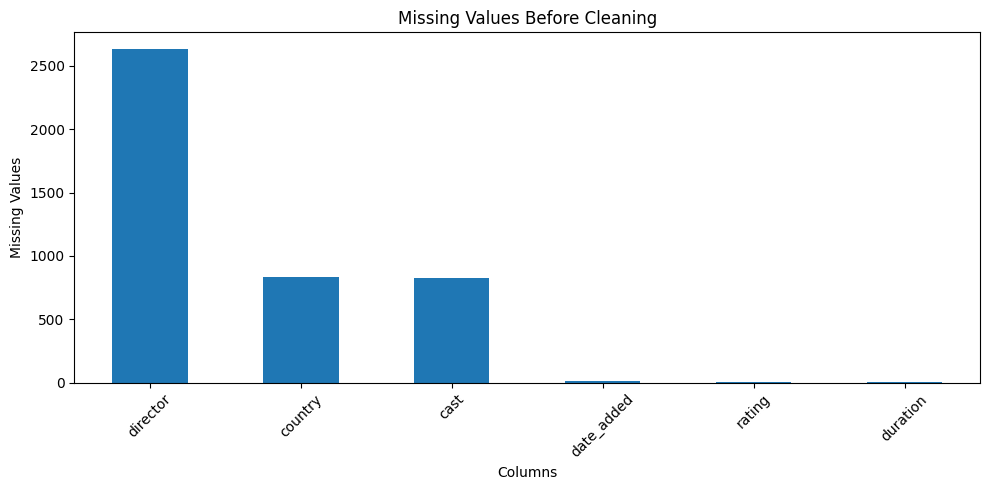

In [ ]:
# ============================================================
# 17. DATA QUALITY VISUALIZATION
# ============================================================

print("\n" + "=" * 60)
print("13. DATA QUALITY VISUALIZATION")
print("=" * 60)

missing_before = (
    df.isnull().sum()
    .sort_values(ascending=False)
)

missing_before = missing_before[
    missing_before > 0
]

if len(missing_before) > 0:

    plt.figure(figsize=(10, 5))

    missing_before.plot(
        kind="bar"
    )

    plt.title(
        "Missing Values Before Cleaning"
    )

    plt.xlabel("Columns")
    plt.ylabel("Missing Values")

    plt.xticks(rotation=45)

    plt.tight_layout()

    plt.show()

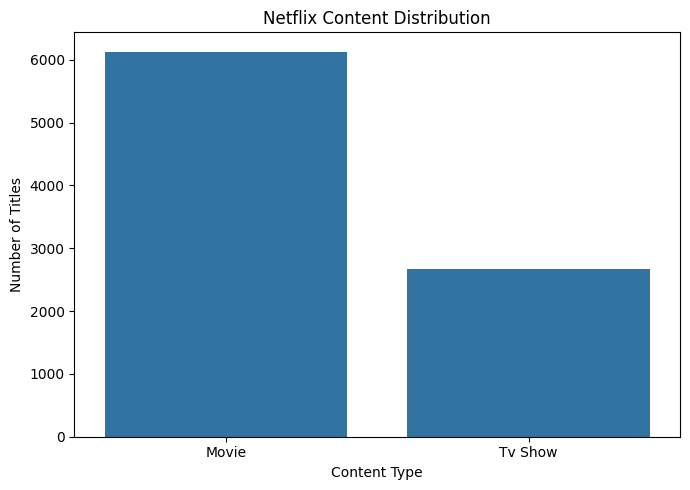

In [ ]:
# ============================================================
# 18. CONTENT TYPE VISUALIZATION
# ============================================================

plt.figure(figsize=(7, 5))

sns.countplot(
    data=clean_df,
    x="type"
)

plt.title(
    "Netflix Content Distribution"
)

plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

plt.tight_layout()

plt.show()


In [ ]:
# ============================================================
# 19. FINAL DATASET PREVIEW
# ============================================================

print("\n" + "=" * 60)
print("14. CLEANED DATASET")
print("=" * 60)

display(clean_df.head(10))



14. CLEANED DATASET


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,Tv Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,Tv Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,Tv Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,Tv Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
5,s6,Tv Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",Unknown,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",Unknown,2021-09-24,2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
8,s9,Tv Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,2021-09-24,2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...


In [ ]:
# ============================================================
# 20. FINAL DATASET INFORMATION
# ============================================================

print("\n" + "=" * 60)
print("15. FINAL DATA QUALITY CHECK")
print("=" * 60)

print("Rows:", clean_df.shape[0])
print("Columns:", clean_df.shape[1])

print(
    "Missing values:",
    clean_df.isnull().sum().sum()
)

print(
    "Duplicate records:",
    clean_df.duplicated().sum()
)

print("\nFinal data types:")
print(clean_df.dtypes)



15. FINAL DATA QUALITY CHECK
Rows: 8807
Columns: 12
Missing values: 10
Duplicate records: 0

Final data types:
show_id         string[python]
type            string[python]
title           string[python]
director        string[python]
cast            string[python]
country         string[python]
date_added      datetime64[ns]
release_year             int64
rating          string[python]
duration        string[python]
listed_in       string[python]
description     string[python]
dtype: object


In [ ]:
# ============================================================
# 21. EXPORT CLEANED DATASET
# ============================================================

cleaned_file = "SWYNEX_cleaned_netflix_dataset.csv"

clean_df.to_csv(
    cleaned_file,
    index=False
)

print("\n✓ Cleaned dataset saved as:")
print(cleaned_file)



✓ Cleaned dataset saved as:
SWYNEX_cleaned_netflix_dataset.csv


In [ ]:
# ============================================================
# 22. EXPORT QUALITY REPORT
# ============================================================

quality_report = pd.DataFrame({
    "Column": clean_df.columns,
    "Data Type": clean_df.dtypes.astype(str),
    "Missing Values": clean_df.isnull().sum(),
    "Unique Values": clean_df.nunique()
})

quality_report.to_csv(
    "SWYNEX_final_data_quality_report.csv",
    index=False
)

comparison.to_csv(
    "SWYNEX_before_after_comparison.csv",
    index=False
)

print("\n✓ Quality reports created.")




✓ Quality reports created.


In [ ]:
# ============================================================
# 23. DOWNLOAD FILES
# ============================================================

print("\n" + "=" * 60)
print("PROJECT COMPLETED")
print("=" * 60)

print("""
Generated files:

1. SWYNEX_cleaned_netflix_dataset.csv
2. SWYNEX_final_data_quality_report.csv
3. SWYNEX_before_after_comparison.csv

These files can be uploaded to your GitHub repository.
""")

files.download(
    "SWYNEX_cleaned_netflix_dataset.csv"
)


PROJECT COMPLETED

Generated files:

1. SWYNEX_cleaned_netflix_dataset.csv
2. SWYNEX_final_data_quality_report.csv
3. SWYNEX_before_after_comparison.csv

These files can be uploaded to your GitHub repository.



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# TASK 2 — EXPLORATORY DATA ANALYSIS

## Objective

The objective of this analysis is to explore the cleaned Netflix dataset, identify patterns and trends, analyze content distribution, and generate meaningful insights using Python.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

In [4]:
df = pd.read_csv("SWYNEX_cleaned_netflix_dataset.csv")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,Tv Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,Tv Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,Tv Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,Tv Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [5]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (8807, 12)

Column Names:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

Data Types:
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

Missing Values:
show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           0
duration         0
listed_in        0
description      0
dtype: int64


In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
show_id,8807,8807,s8807,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,8807,2,Movie,6131,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,8807,8806,Consequences,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
director,8807,4529,Unknown,2634,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cast,8807,7693,Unknown,825,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,8807,749,United States,2818,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_added,8797,1714,2020-01-01,110,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_year,8807.0,NaN,NaN,NaN,2014.180198,8.819312,1925.0,2013.0,2017.0,2019.0,2021.0
rating,8807,18,TV-MA,3207,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,8807,221,1 Season,1793,NaN,NaN,NaN,NaN,NaN,NaN,NaN


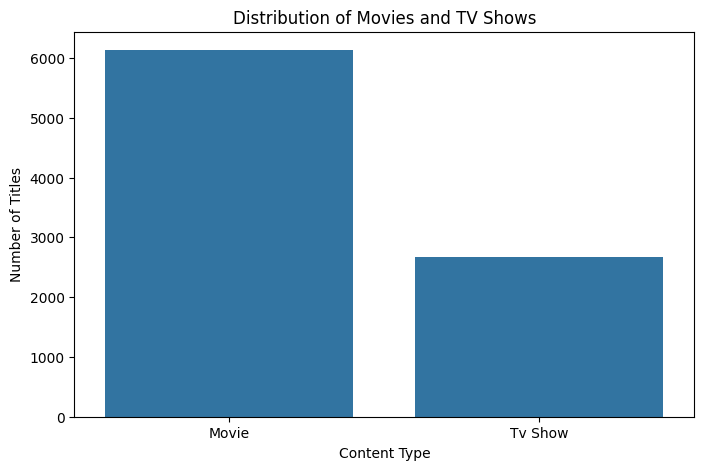

In [7]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="type")

plt.title("Distribution of Movies and TV Shows")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

plt.show()

In [8]:
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")

df["added_year"] = df["date_added"].dt.year

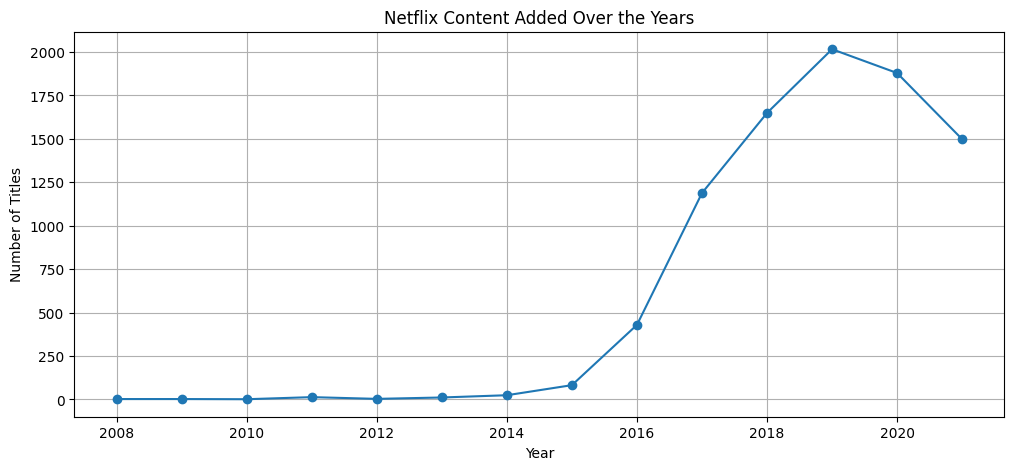

In [9]:
yearly_content = df["added_year"].value_counts().sort_index()

plt.figure(figsize=(12,5))

plt.plot(yearly_content.index, yearly_content.values, marker="o")

plt.title("Netflix Content Added Over the Years")
plt.xlabel("Year")
plt.ylabel("Number of Titles")

plt.grid(True)
plt.show()

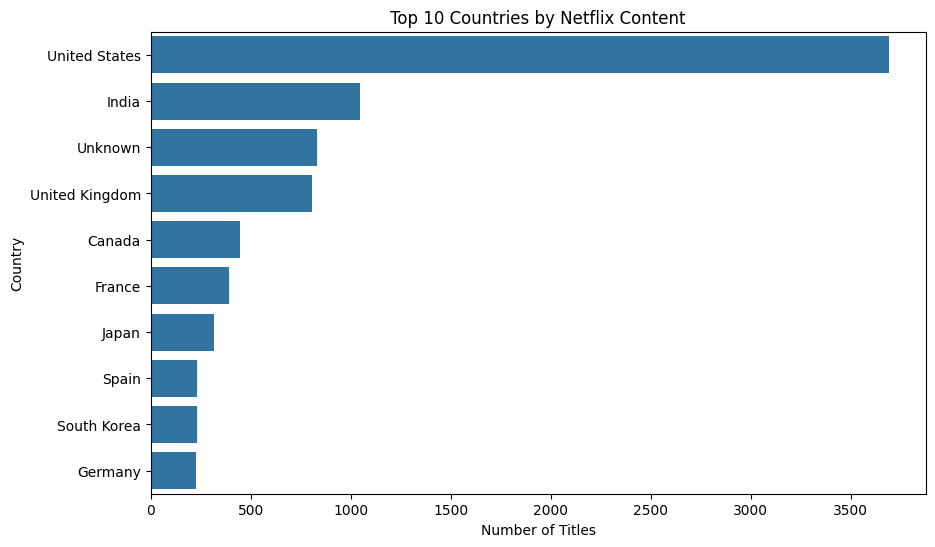

In [10]:
countries = (
    df["country"]
    .dropna()
    .str.split(", ")
    .explode()
)

top_countries = countries.value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_countries.values,
    y=top_countries.index
)

plt.title("Top 10 Countries by Netflix Content")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.show()

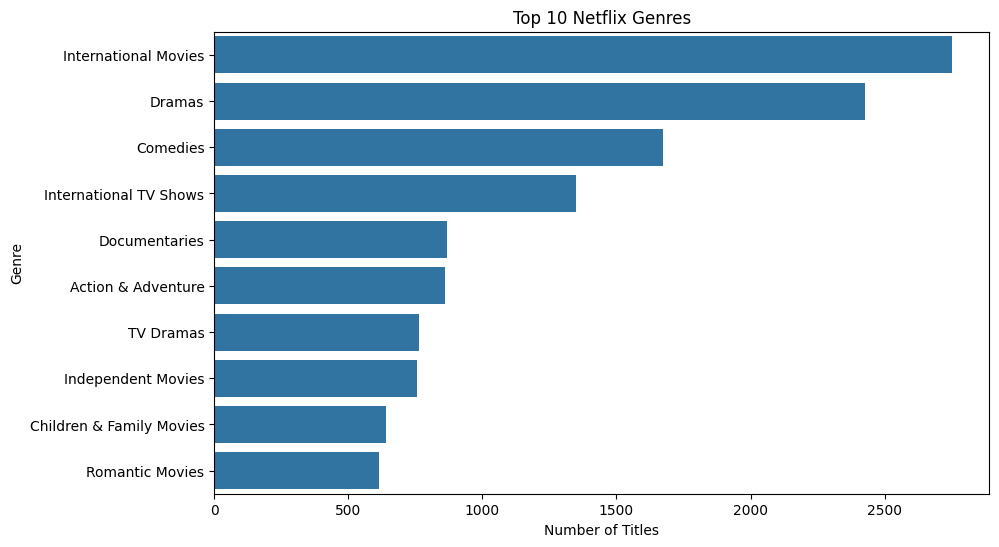

In [11]:
genres = (
    df["listed_in"]
    .dropna()
    .str.split(", ")
    .explode()
)

top_genres = genres.value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index
)

plt.title("Top 10 Netflix Genres")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

plt.show()

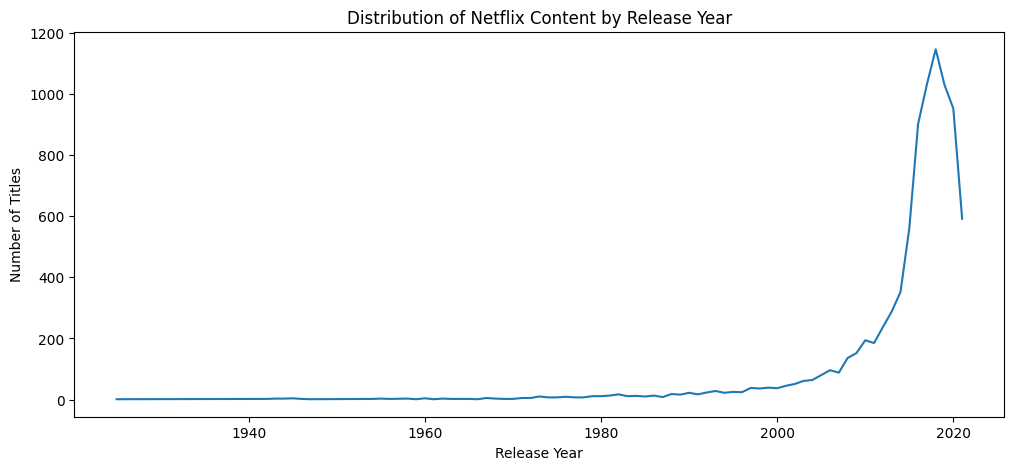

In [12]:
release_year_counts = df["release_year"].value_counts().sort_index()

plt.figure(figsize=(12,5))

plt.plot(
    release_year_counts.index,
    release_year_counts.values
)

plt.title("Distribution of Netflix Content by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.show()

In [13]:
movies = df[df["type"] == "Movie"].copy()

movies["duration_minutes"] = (
    movies["duration"]
    .str.extract(r"(\d+)")
    .astype(float)
)

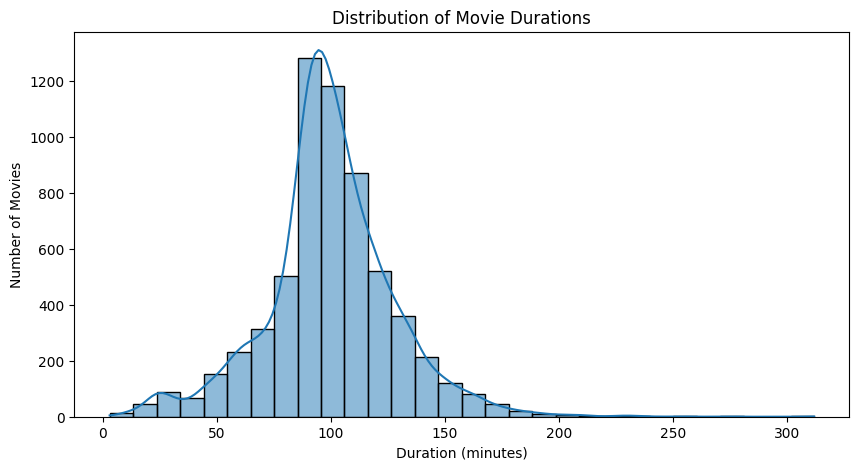

In [14]:
plt.figure(figsize=(10,5))

sns.histplot(
    movies["duration_minutes"].dropna(),
    bins=30,
    kde=True
)

plt.title("Distribution of Movie Durations")
plt.xlabel("Duration (minutes)")
plt.ylabel("Number of Movies")

plt.show()

In [15]:
average_duration = movies["duration_minutes"].mean()

print("Average Movie Duration:", round(average_duration, 2), "minutes")

Average Movie Duration: 99.58 minutes


In [16]:
print("Shortest Movie:",
      movies["duration_minutes"].min(), "minutes")

print("Longest Movie:",
      movies["duration_minutes"].max(), "minutes")

Shortest Movie: 3.0 minutes
Longest Movie: 312.0 minutes


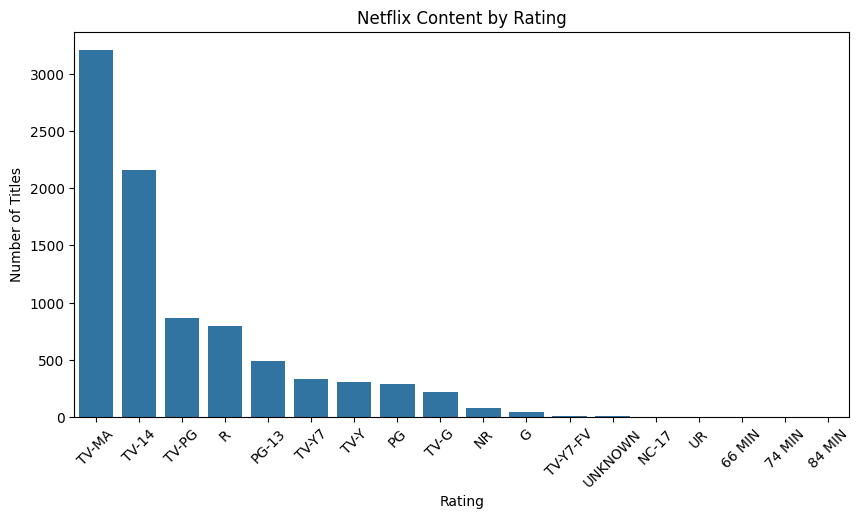

In [17]:
rating_counts = df["rating"].value_counts()

plt.figure(figsize=(10,5))

sns.barplot(
    x=rating_counts.index,
    y=rating_counts.values
)

plt.title("Netflix Content by Rating")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.show()

In [18]:
numeric_df = df.select_dtypes(include=np.number)

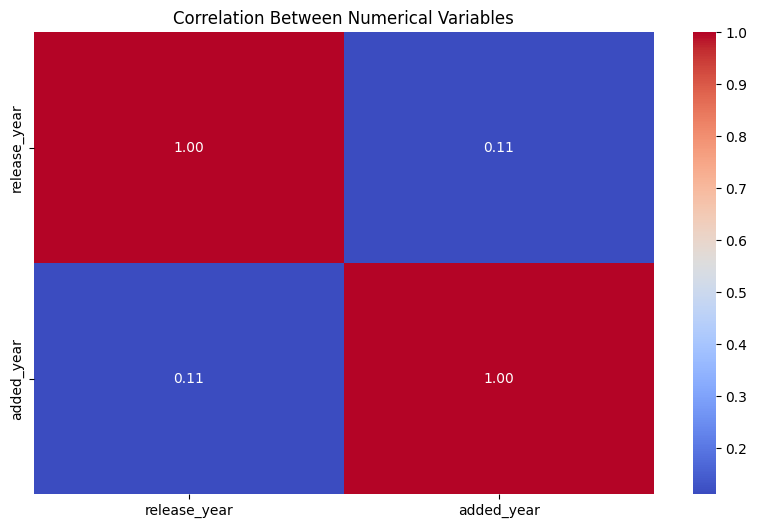

In [19]:
plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Numerical Variables")

plt.show()

In [20]:
Q1 = movies["duration_minutes"].quantile(0.25)
Q3 = movies["duration_minutes"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = movies[
    (movies["duration_minutes"] < lower_bound) |
    (movies["duration_minutes"] > upper_bound)
]

print("Number of duration outliers:", len(outliers))

Number of duration outliers: 450


In [21]:
outliers[["title", "duration_minutes"]].head(10)

,title,duration_minutes
22,Avvai Shanmughi,161.0
24,Jeans,166.0
45,My Heroes Were Cowboys,23.0
71,A StoryBots Space Adventure,13.0
73,King of Boys,182.0
166,Once Upon a Time in America,229.0
177,The Guns of Navarone,156.0
202,Kyaa Kool Hai Hum,165.0
341,Magnolia,189.0
392,Django Unchained,165.0


In [22]:
summary = {
    "Total Titles": len(df),
    "Movies": (df["type"] == "Movie").sum(),
    "TV Shows": (df["type"] == "TV Show").sum(),
    "Unique Ratings": df["rating"].nunique(),
    "Unique Countries": countries.nunique(),
    "Unique Genres": genres.nunique()
}

summary_df = pd.DataFrame(
    summary.items(),
    columns=["Metric", "Value"]
)

summary_df

,Metric,Value
0,Total Titles,8807
1,Movies,6131
2,TV Shows,0
3,Unique Ratings,18
4,Unique Countries,128
5,Unique Genres,42


In [ ]:
# Key Insights

### Insight 1 — Content Type
...

### Insight 2 — Content Growth
...

### Insight 3 — Country Distribution
...

### Insight 4 — Genre Distribution
...

### Insight 5 — Movie Duration
...

### Insight 6 — Ratings
...

In [23]:
type_percentage = df["type"].value_counts(normalize=True) * 100
print(type_percentage)

type
Movie      69.615079
Tv Show    30.384921
Name: proportion, dtype: float64


In [ ]:
# Conclusion

The exploratory data analysis provided an overview of Netflix's content library by examining content types, release trends, countries, genres, ratings, and movie durations. The analysis helped identify major patterns in the dataset and highlighted differences in content distribution across categories. These findings demonstrate how exploratory data analysis can be used to transform a cleaned dataset into meaningful and interpretable insights.

In [24]:
plt.savefig("content_type.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [25]:
plt.savefig("yearly_trend.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [26]:
plt.savefig("top_countries.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [27]:
plt.savefig("genre_distribution.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [28]:
plt.savefig("duration_analysis.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>